In [17]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KernelDensity

In [18]:
# prepare and combine latent data 
df_pfc = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_final/sameregion_hc_seed0/latent_variables_epoch100_vaeHC1.csv')
df_hc = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_final/sameregion_hc_seed0/latent_variables_epoch100_vaeHC2.csv')
df = pd.concat([df_pfc, df_hc])
df = df.reset_index()
df = df.drop(columns='index')
df

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual
0,-31.910070,-23.854944,-21.333069,-18.637726,-15.781756,-13.827662,-11.221580,-5.533496,-19.568138,-9.628607,1,-1.291204,HC1,D2,-0.673075
1,-35.927940,-23.681187,-22.827723,-25.125546,-17.821835,-14.974473,-13.858206,-5.550820,-18.342407,-12.658295,1,-1.291204,HC1,D2,-0.673075
2,-26.061354,-23.159096,-22.585620,-20.513440,-17.881770,-14.589744,-11.314239,-8.092881,-16.514530,-7.518422,1,-1.291204,HC1,D2,-0.673075
3,-36.211240,-28.058098,-29.645468,-25.340750,-18.530134,-12.894540,-10.807932,-9.341749,-8.351610,-9.629206,1,-1.291204,HC1,D2,-0.673075
4,-21.955551,-15.587837,-16.504318,-14.398881,-12.055207,-9.295938,-10.484478,-5.010187,-7.161200,-6.940970,1,-1.291204,HC1,D2,-0.673075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16987,-16.720228,-11.241321,-12.084551,-6.494958,-4.136155,1.944697,6.146580,7.751170,8.775466,14.220642,1,-0.207663,HC2,28,-0.576731
16988,-15.718027,-12.822207,-10.816713,-6.105814,-2.908929,-3.000949,-0.555581,7.722070,8.029409,13.377908,1,-0.207663,HC2,28,-0.576731
16989,-27.026852,-18.431387,-13.525400,-12.801739,-1.624524,-0.466361,8.852939,11.561608,14.026697,21.524971,1,-0.207663,HC2,28,-0.576731
16990,-16.023120,-9.960956,-8.985063,-3.961967,-2.070056,-1.293310,4.736605,9.021687,7.220205,13.650121,1,-0.207663,HC2,28,-0.576731


In [19]:
# functions to compute phenotypic projection 
def line_coordinates_euclidean(A, B, P):
    A = np.array(A)
    B = np.array(B)
    P = np.array(P)

    u_hat = (B - A) / np.linalg.norm(B - A)  # Unit direction vector from A to B
    s = np.dot(P - A, u_hat)                # Signed distance from A
    P_proj = A + s * u_hat                  # Projected point on the line

    return P_proj, s

def project_row(row, coord_cols, sus, res):
    coords = row[coord_cols].values
    proj, dist = line_coordinates_euclidean(sus, res, coords)
    return pd.Series({'Projected': proj,'Signed_Distance': dist})

In [20]:
# calculate phenotypic projection
coord_cols = df.columns[:10]
df[coord_cols] = df[coord_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# find most susceptible/resilience strains
strain_order = (df.sort_values('14-6-residual', ascending=True)['strain'].unique())
strain_sus = strain_order[0]
strain_res = strain_order[-1]

sus = (df[df['strain'] == strain_sus][coord_cols].apply(np.mean, axis=0).values)
res = (df[df['strain'] == strain_res][coord_cols].apply(np.mean, axis=0).values)

proj = df.apply(lambda x: project_row(x, coord_cols, sus, res), axis=1)
df = pd.concat([
    df.reset_index(drop=True),
    pd.DataFrame(proj['Projected'].tolist(), columns=[f'Proj_{i+1}' for i in range(10)]),
    proj[['Signed_Distance']]], axis=1)

sus_cen = (df[df['bin'] == 0][coord_cols].apply(np.mean, axis=0).values)
res_cen = (df[df['bin'] == 3][coord_cols].apply(np.mean, axis=0).values)

_, s_sus_cen = line_coordinates_euclidean(sus, res, sus_cen)
_, s_res_cen = line_coordinates_euclidean(sus, res, res_cen)
print("Signed distance (sus_cen, res_cen):", s_sus_cen, s_res_cen)

_, sus_strain = line_coordinates_euclidean(sus, res, sus)
_, res_strain = line_coordinates_euclidean(sus, res, res)
print("Signed distance (sus_strain, res_strain):", sus_strain, res_strain)

# Rename last column as PP (Phenotypic Projection)
df.rename(columns={df.columns[-1]: 'PP'}, inplace=True)

Signed distance (sus_cen, res_cen): -0.9965749267806869 43.03616380573768
Signed distance (sus_strain, res_strain): 0.0 42.51292663560252


/tmp/ipykernel_1443380/3204273349.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_1443380/3204273349.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


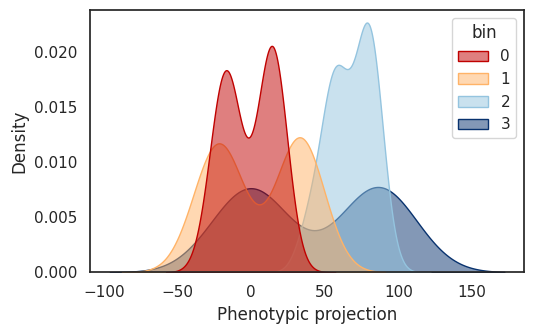

In [21]:
# plot phenotypic projection
sns.set(style="white")
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
bin_order = ['0', '1', '2', '3']
legend_labels = ['Strong susceptible', 'Weak susceptible', 'Weak resilient', 'Strong resilient']
temp = df
plt.figure(figsize=(5.5, 3.5))
ax = sns.kdeplot(data=temp, x='PP',hue="bin",palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False)
if not ax.legend_:
    plt.legend(title="bin",labels=temp["bin"].unique(),bbox_to_anchor=(1.05, 1))
plt.title("")
plt.xlabel('Phenotypic projection')
plt.tight_layout()
plt.show()

In [22]:
def compute_kde_peak(values, bandwidth=0.1, grid_size=1000):
    """Estimate KDE peak (mode) location."""
    values = values[:, None]
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(values)
    grid = np.linspace(values.min(), values.max(), grid_size)[:, None]
    log_dens = kde.score_samples(grid)
    peak = grid[np.argmax(log_dens)][0]
    return peak

In [23]:
def compute_osd(df, projection_col='PP', bin_col='bin', bandwidth=0.1):
    # Step 1: Compute KDE peaks for each bin
    bins_sorted = sorted(df[bin_col].unique())
    peak_locs = []
    for b in bins_sorted:
        values = df[df[bin_col] == b][projection_col].values
        if len(values) > 1:
            peak = compute_kde_peak(values, bandwidth=bandwidth)
        else:
            peak = np.nan
        peak_locs.append(peak)

    # Step 2: Spearman correlation
    rho, _ = spearmanr(bins_sorted, peak_locs)

    # Step 3: Pairwise adjacent AUCs → Somers' D
    D_list = []
    for i in range(len(bins_sorted) - 1):
        b_low, b_high = bins_sorted[i], bins_sorted[i + 1]
        df_pair = df[df[bin_col].isin([b_low, b_high])].copy()
        df_pair['label'] = (df_pair[bin_col] == b_high).astype(int)
        from sklearn.metrics import roc_auc_score
        auc = roc_auc_score(df_pair['label'], df_pair[projection_col])
        D = 2 * auc - 1
        D_list.append(D)

    D_avg = np.mean(D_list)
    osd = rho * D_avg

    return {
        'rho_spearman': rho,
        'somers_d_adjacent': D_avg,
        'osd': osd,
        'peak_locations': dict(zip(bins_sorted, peak_locs)),
        'pairwise_D': D_list,
    }

In [24]:
osd_result = compute_osd(df)
print("Spearman ρ:", osd_result['rho_spearman'])
print("Mean Somers' D:", osd_result['somers_d_adjacent'])
print("OSD:", osd_result['osd'])

Spearman ρ: 1.0
Mean Somers' D: 0.34711070490568696
OSD: 0.34711070490568696
